In this notebook, we will try to estimate the parameters of a Thomas process using the periodogram, with a predefined theoretical expression of the jacobian that we'll assign to the `jac` argument of the `minimize` function.

**Imports**

In [1]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import *
import json

**Processs generation**

First, we generate a point process with a given tuple of paremeters:

In [2]:
with open('../../parameters/thomas-process-m-09.json', 'r') as file:
    params = json.load(file)

In [3]:
W = params['W']
w, h = W
lam_p = params['lam_p']
nu = params['nu']
sig = params['sig']

In [4]:
thomas_process = ThomasProcess(lam_p, nu, sig)
parents, points_thomas = thomas_process.generate(W, seed=46)

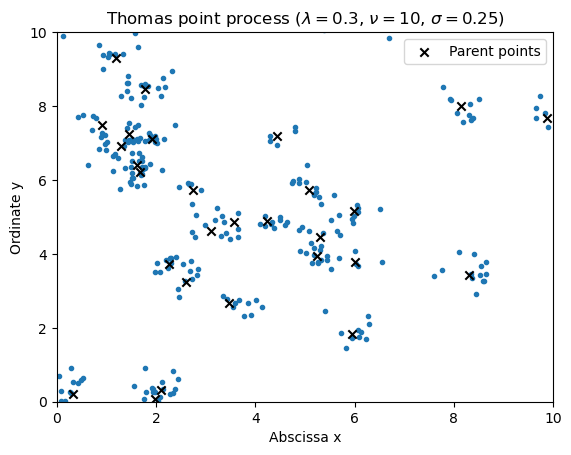

In [5]:
display(parents, points_thomas, window=(10, 10), title=fr"Thomas point process ($\lambda = {lam_p}$, $\nu = {nu}$, $\sigma = {sig}$)")

In [6]:
lambda_hat = intensity(points_thomas, W)  # Estimator of the global intensity lam = lam_p*nu

In [7]:
threshold = 0.2
r_values = np.linspace(threshold, w/5, 500)
I_values = periodogram_bessel(points_thomas, W, r_values)

In [8]:
def contrast_aux(theta):  # theta = [nu, sig]
    f_theo = f2(r_values, lambda_hat, theta)
    dr = r_values[1] - r_values[0]
    return contrast(I_values, f_theo, dr)

In [9]:
theta0 = [20, 0.5]  # Initial guess

bounds = [(1e-6, None), (1e-6, None)]  # Positivity constraints

result = minimize(contrast_aux, theta0, method='L-BFGS-B', bounds=bounds)
nu_hat, sig_hat = result.x

print('Estimated parameters:\n------------------')
# print(f'estimated_lam_p = {lam_p_hat:.3f}')
print(f'estimated_nu = {nu_hat:.3f}')
print(f'estimated_sig = {sig_hat:.3f}')
print('\nReal parameters:\n------------------')
print(f'lam_p = {lam_p:.3f}')
print(f'nu = {nu:.3f}')
print(f'sig = {sig:.3f}')
print('\nRelative error:\n------------------')
# print(f'lam_p --> {100*abs(lam_p - lam_p_hat)/lam_p:.2f} %')
print(f'nu --> {100*abs(nu - nu_hat)/nu:.2f} %')
print(f'sig --> {100*abs(sig - sig_hat)/sig:.2f} %')

print(result)

Estimated parameters:
------------------
estimated_nu = 10.251
estimated_sig = 0.255

Real parameters:
------------------
lam_p = 0.300
nu = 10.000
sig = 0.250

Relative error:
------------------
nu --> 2.51 %
sig --> 2.17 %
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 5.567655264197283
        x: [ 1.025e+01  2.554e-01]
      nit: 12
      jac: [-7.105e-07  1.039e-05]
     nfev: 66
     njev: 22
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
